# Makemore Part 1: Bigram 문자 수준 언어 모델

> 📺 **강의**: Andrej Karpathy - "The spelled-out intro to language modeling: building makemore"
> 🔗 https://www.youtube.com/watch?v=PaCmpygFfXo

**Makemore** = 주어진 데이터와 비슷한 것을 더 만들어내는 모델

| 모델 | 설명 |
|------|------|
| **Bigram (카운팅 기반)** | 이전 문자만 보고 다음 문자 예측 |
| **Bigram (신경망 기반)** | 동일하지만 신경망으로 구현 |

---
## Part 1: Bigram 언어 모델 (카운팅 기반)
### 📺 00:00 - 02:30 | 소개 및 데이터셋

In [1]:
# names.txt 로드
words = open('names.txt', 'r').read().splitlines()
print(f'총 이름 수: {len(words)}')
print(f'처음 10개: {words[:10]}')
print(f'최소 길이: {min(len(w) for w in words)}')
print(f'최대 길이: {max(len(w) for w in words)}')

총 이름 수: 32033
처음 10개: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
최소 길이: 2
최대 길이: 15


---
### 📺 02:30 - 08:00 | Bigram이란?

**Bigram = 연속된 두 문자의 쌍**

- "이전 문자가 X일 때 다음 문자는 무엇일까?"만 본다
- `<S>`: 시작 토큰, `<E>`: 끝 토큰

In [2]:
# "emma"의 bigram 예시
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)
    print('---')

<S> e
e m
m m
m a
a <E>
---
<S> o
o l
l i
i v
v i
i a
a <E>
---
<S> a
a v
v a
a <E>
---


---
### 📺 08:00 - 18:00 | 카운트 행렬 구축

- `N[i, j]` = 문자 i 다음에 문자 j가 나온 횟수
- 행(row) = 현재 문자, 열(column) = 다음 문자

In [3]:
import torch

# 27x27 카운트 행렬 (26개 알파벳 + 특수토큰 '.')
N = torch.zeros((27, 27), dtype=torch.int32)

# 문자 <-> 인덱스 매핑
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  # 문자 → 숫자
stoi['.'] = 0  # 특수토큰 (시작/끝)
itos = {i:s for s,i in stoi.items()}  # 숫자 → 문자

# 카운트 수집
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

print('카운트 행렬 크기:', N.shape)
print('예: . 다음에 a가 나온 횟수:', N[stoi['.'], stoi['a']].item())

카운트 행렬 크기: torch.Size([27, 27])
예: . 다음에 a가 나온 횟수: 4410


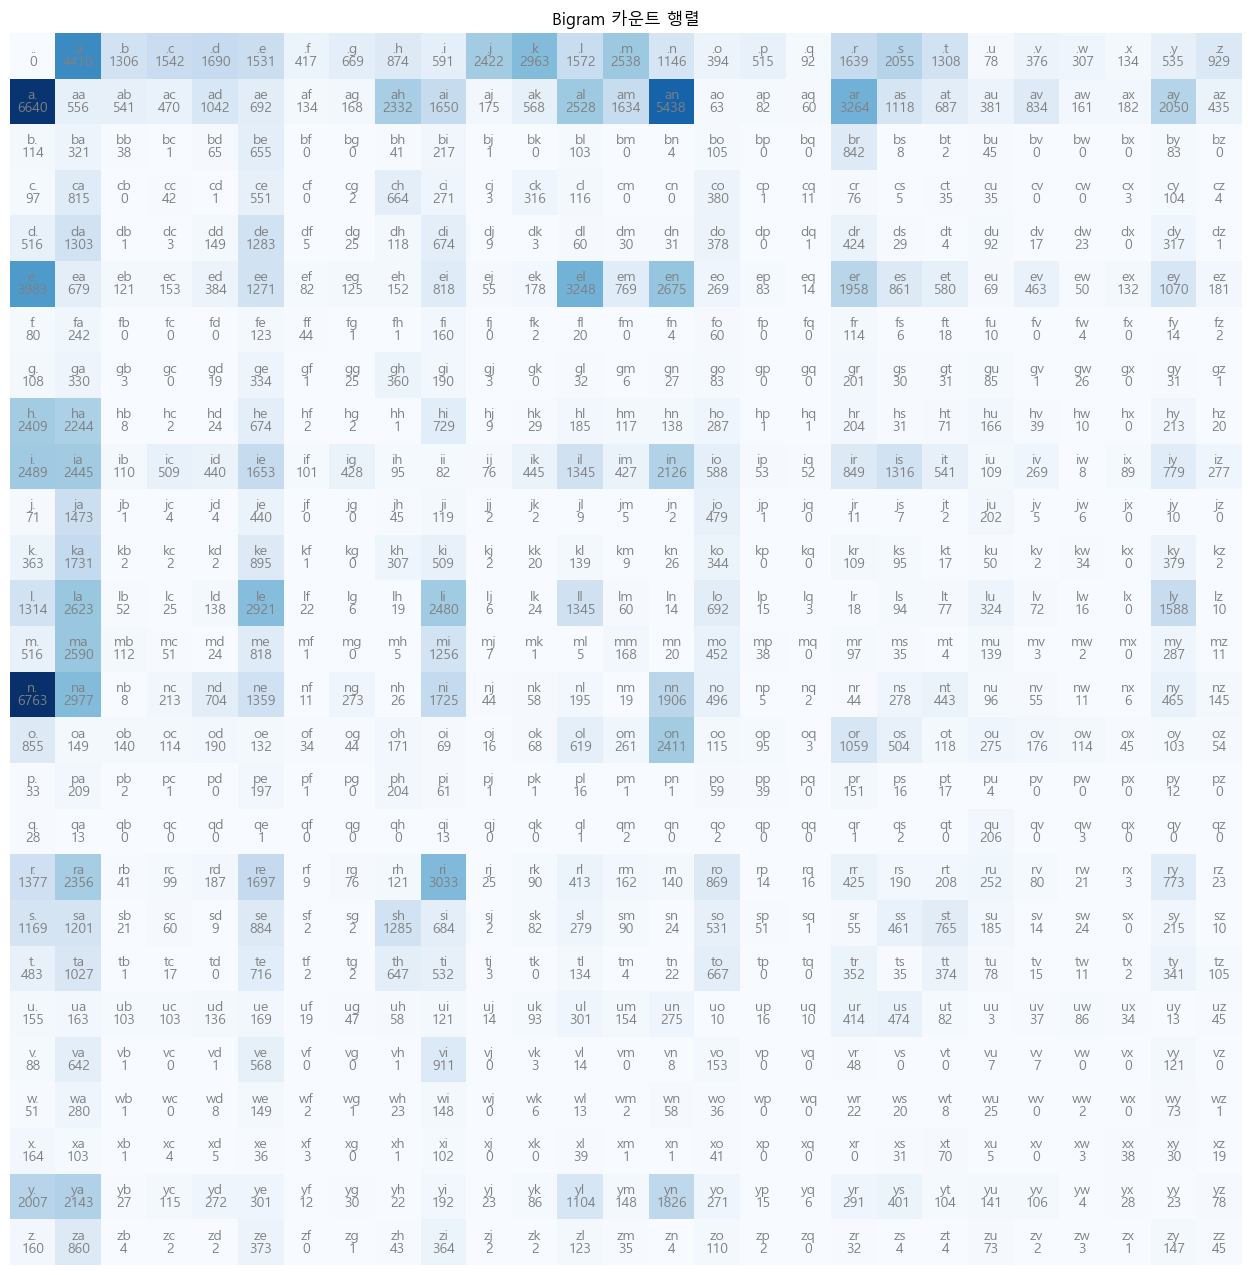

In [4]:
# 카운트 행렬 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
%matplotlib inline

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')
plt.title('Bigram 카운트 행렬')
plt.show()

---
### 📺 18:00 - 28:00 | 확률 분포로 변환

카운트 → 확률: 각 행의 합이 1이 되도록 정규화

In [5]:
# 각 행을 확률 분포로 정규화
P = (N + 1).float()  # +1: 라플라스 스무딩 (0 확률 방지)
P = P / P.sum(dim=1, keepdim=True)  # 행별로 합이 1이 되도록

# 확인: 'a' 다음에 올 각 문자의 확률
print("'a' 다음 확률 분포 (상위 5개):")
probs_a = P[stoi['a']]
top5 = probs_a.topk(5)
for idx, prob in zip(top5.indices, top5.values):
    print(f"  '{itos[idx.item()]}': {prob.item():.4f}")
print(f'합계: {probs_a.sum().item():.4f}')

'a' 다음 확률 분포 (상위 5개):
  '.': 0.1958
  'n': 0.1604
  'r': 0.0963
  'l': 0.0746
  'h': 0.0688
합계: 1.0000


---
### 📺 28:00 - 38:00 | 이름 생성 (샘플링)

`torch.multinomial`: 확률 분포에서 랜덤 샘플링 (확률이 높은 문자가 더 자주 선택됨)

In [6]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0  # 시작 토큰 '.'
    while True:
        p = P[ix]  # 현재 문자에서의 확률 분포
        ix = torch.multinomial(p, num_samples=1,
                               replacement=True,
                               generator=g).item()
        out.append(itos[ix])
        if ix == 0:  # 끝 토큰
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


---
### 📺 38:00 - 50:00 | 모델 평가: 손실 함수

**Negative Log Likelihood (NLL)**
- 확률 → log 확률 → 음수 → 평균
- 낮을수록 좋음
- 완전 랜덤: NLL ≈ 3.3 (`-log(1/27)`)

In [7]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood / n
print(f'Average NLL: {nll:.4f}')
print(f'(완전 랜덤 모델이면: {-torch.log(torch.tensor(1/27.0)):.4f})')

Average NLL: 2.4544
(완전 랜덤 모델이면: 3.2958)


---
### 📺 50:00 - 55:00 | 스무딩 (Smoothing)

**문제:** 학습 데이터에 없는 bigram → 확률 0 → `log(0) = -∞`

**해결:** 라플라스 스무딩 (`N + 1`)
- 클수록 더 균등한 분포 (smoothed)
- 작을수록 더 뾰족한 분포 (peaked)

In [8]:
# 스무딩 값에 따른 NLL 비교
for smooth in [0, 0.01, 0.1, 1, 5, 10]:
    P_temp = (N + smooth).float()
    P_temp = P_temp / P_temp.sum(dim=1, keepdim=True)

    log_likelihood = 0.0
    n = 0
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            prob = P_temp[stoi[ch1], stoi[ch2]]
            if prob > 0:
                log_likelihood += torch.log(prob)
            else:
                log_likelihood += torch.tensor(float('-inf'))
            n += 1
    print(f'smooth={smooth:>5}: NLL = {(-log_likelihood/n).item():.4f}')

smooth=    0: NLL = 2.4541
smooth= 0.01: NLL = 2.4541
smooth=  0.1: NLL = 2.4543
smooth=    1: NLL = 2.4544
smooth=    5: NLL = 2.4574
smooth=   10: NLL = 2.4616


---
## Part 2: Bigram 모델 (신경망 기반)

### 📺 55:00 - 01:05:00 | 왜 신경망인가?

**카운팅 방식의 한계:**
- Trigram (3개) → 27³ = 19,683개 조합
- 4-gram → 27⁴ = 531,441개 조합
- 대부분이 0이 됨 (sparse)

**신경망의 장점:**
- 파라미터 공유로 효율적
- 더 긴 컨텍스트 처리 가능
- 일반화 능력

---
### 📺 01:05:00 - 01:15:00 | 입력 표현: One-Hot Encoding

- 신경망은 숫자 입력 필요
- 문자 간 순서/크기 관계가 없음 (a < b 아님)
- One-hot은 모든 문자를 동등하게 표현

In [9]:
import torch.nn.functional as F

# 문자 'e'를 one-hot으로 변환
xenc = F.one_hot(torch.tensor(5), num_classes=27).float()
print('문자 e의 one-hot:')
print(xenc)
print(f'5번째 위치만 1: {xenc[5].item()}')

문자 e의 one-hot:
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])
5번째 위치만 1: 1.0


---
### 📺 01:15:00 - 01:30:00 | 신경망 구조

```
입력 x (one-hot, 27차원)
      ↓
  W (27x27 가중치 행렬)
      ↓
  logits (27차원)
      ↓
  softmax → 확률 분포
```

In [10]:
# 학습 데이터 준비
xs, ys = [], []  # 입력, 정답
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f'총 학습 샘플 수: {num}')

총 학습 샘플 수: 228146


In [11]:
# 신경망 파라미터: 27x27 가중치 행렬
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [12]:
# 순전파 (Forward Pass) 한 번 해보기

# 1. One-hot 인코딩
xenc = F.one_hot(xs, num_classes=27).float()
print(f'입력 shape: {xenc.shape}')  # (N, 27)

# 2. 행렬 곱 → logits
logits = xenc @ W  # (N, 27) @ (27, 27) → (N, 27)
print(f'logits shape: {logits.shape}')

# 3. Softmax → 확률
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
print(f'probs shape: {probs.shape}')
print(f'첫 번째 샘플의 확률 합: {probs[0].sum().item():.4f}')

입력 shape: torch.Size([228146, 27])
logits shape: torch.Size([228146, 27])
probs shape: torch.Size([228146, 27])
첫 번째 샘플의 확률 합: 1.0000


---
### 📺 01:30:00 - 01:45:00 | 손실 함수와 역전파

**Cross Entropy Loss:**
- 정답 문자의 확률을 최대화
- = 정답의 `-log(확률)`을 최소화

```python
probs[torch.arange(num), ys]  # 정답 문자의 확률만 추출
.log()                        # log 확률
.mean()                       # 평균
-                             # 음수 (NLL)
```

In [13]:
# 손실 계산
loss = -probs[torch.arange(num), ys].log().mean()
print(f'초기 loss: {loss.item():.4f}')

초기 loss: 3.7590


---
### 📺 01:45:00 - 01:55:00 | 학습 루프

In [14]:
# 가중치 재초기화
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# 학습 루프
for i in range(200):
    # Forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean()

    # Backward pass
    W.grad = None
    loss.backward()

    # Update
    W.data += -50 * W.grad

    if i % 20 == 0 or i == 199:
        print(f'Step {i:>3}: loss = {loss.item():.4f}')

Step   0: loss = 3.7590
Step  20: loss = 2.5728
Step  40: loss = 2.5087
Step  60: loss = 2.4880
Step  80: loss = 2.4783
Step 100: loss = 2.4727
Step 120: loss = 2.4690
Step 140: loss = 2.4666
Step 160: loss = 2.4648
Step 180: loss = 2.4634
Step 199: loss = 2.4624


---
### 📺 01:55:00 - 01:57:00 | 신경망으로 이름 생성

카운팅 방식과 동일한 결과가 나옴!

In [16]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(dim=1, keepdim=True)

        ix = torch.multinomial(p, num_samples=1,
                               replacement=True,
                               generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


---
## 핵심 개념 정리

### 1. 언어 모델
```
P(다음 토큰 | 이전 토큰들)
- Bigram: P(다음 | 직전 1개)
- GPT:    P(다음 | 직전 수천 개)
```

### 2. 카운팅 vs 신경망

| 카운팅 | 신경망 |
|--------|--------|
| 빈도수 직접 세기 | 파라미터 학습 |
| 테이블 저장 | 가중치 행렬 |
| 확장성 제한 | 확장 용이 |
| 스무딩 필요 | 자연스럽게 일반화 |

### 3. Softmax
```
logits → exp() → 정규화 → 확률 분포 (합=1, 모두 양수)
```

### 4. Cross Entropy Loss
```
loss = -log(P(정답))
- 확률 1.0 → loss 0
- 확률 0.0 → loss ∞
```